In [19]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np

data_dir = Path("../data/raw")

In [20]:
image_paths = list(data_dir.rglob("*.jpg"))
print(f"Number of images: {len(image_paths)}")

Number of images: 9997


In [21]:
widths, heights = [], []
for p in image_paths:
    img = Image.open(p)
    w, h = img.size
    widths.append(w)
    heights.append(h)

print(f"Width: min={min(widths)}, max={max(widths)}, avg={np.mean(widths):.0f}")
print(f"Height: min={min(heights)}, max={max(heights)}, avg={np.mean(heights):.0f}")

Width: min=135, max=1024, avg=605
Height: min=101, max=1024, avg=520


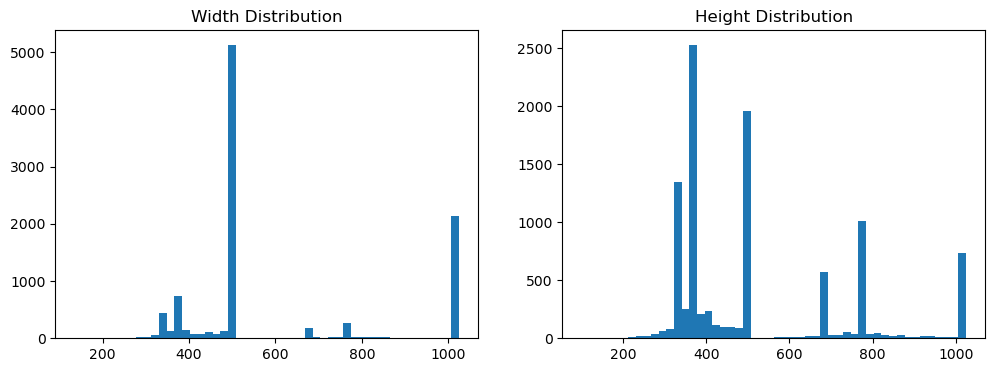

In [22]:
plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.hist(widths, bins=50)
plt.title("Width Distribution")
plt.subplot(1,2,2)
plt.hist(heights, bins=50)
plt.title("Height Distribution")
plt.show()

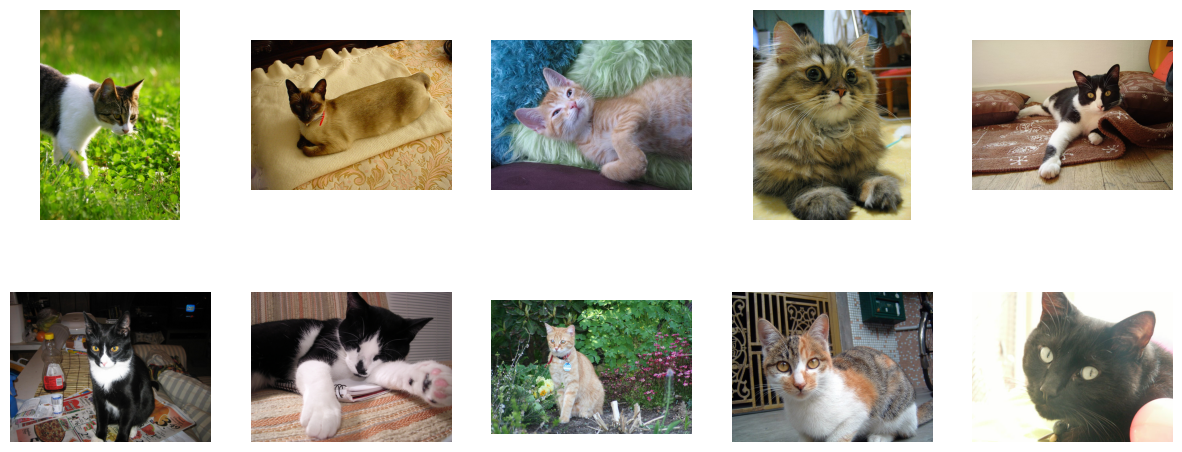

In [23]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
sample = np.random.choice(image_paths, 10)
for ax, p in zip(axes.flatten(), sample):
    ax.imshow(Image.open(p))
    ax.axis("off")
plt.show()

In [24]:
# potentially problematic images
too_small = []

for p in image_paths:
    img = Image.open(p)
    w, h = img.size
    
    # too small images
    if w < 64 or h < 64:
        too_small.append(p)

print(f"Too small (<64px): {len(too_small)}")

Too small (<64px): 0


In [30]:
for size in [64, 128, 256]:
    count = sum(w >= size and h >= size for w, h in zip(widths, heights))
    print(f"Images >= {size}x{size}: {count} ({count/len(image_paths):.1%})")

Images >= 64x64: 9997 (100.0%)
Images >= 128x128: 9996 (100.0%)
Images >= 256x256: 9943 (99.5%)


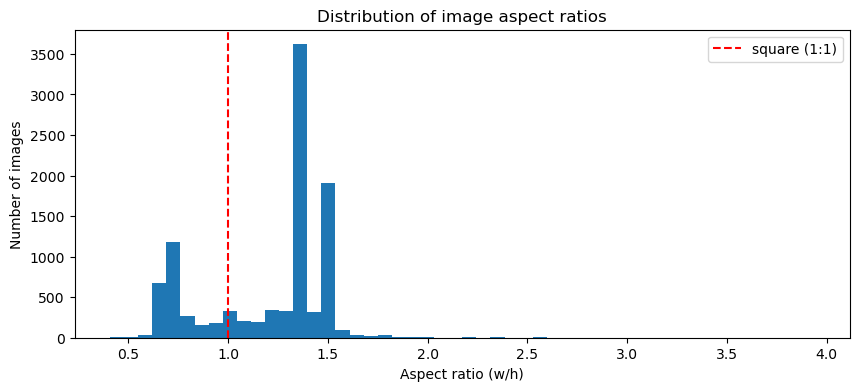

Square (0.9-1.1): 682
Horizontal (>1.2): 6715
Vertical (<0.8): 2031


In [25]:
aspect_ratios = [w/h for w, h in zip(widths, heights)]

plt.figure(figsize=(10, 4))
plt.hist(aspect_ratios, bins=50)
plt.axvline(1.0, color='red', linestyle='--', label='square (1:1)')
plt.xlabel("Aspect ratio (w/h)")
plt.ylabel("Number of images")
plt.title("Distribution of image aspect ratios")
plt.legend()
plt.show()

print(f"Square (0.9-1.1): {sum(0.9 < r < 1.1 for r in aspect_ratios)}")
print(f"Horizontal (>1.2): {sum(r > 1.2 for r in aspect_ratios)}")
print(f"Vertical (<0.8): {sum(r < 0.8 for r in aspect_ratios)}")

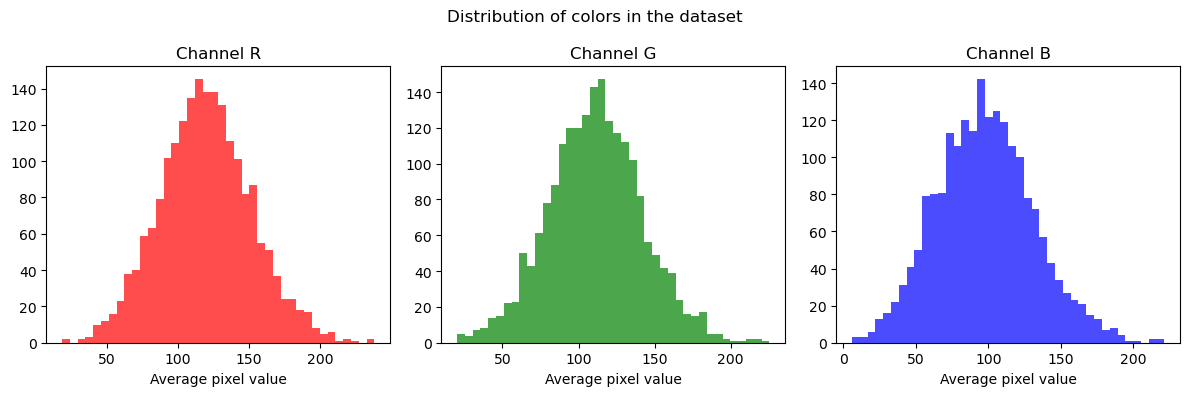

Average R: 119.7
Average G: 111.1
Average B: 97.8


In [26]:
mean_r, mean_g, mean_b = [], [], []

for p in image_paths[:2000]:
    arr = np.array(Image.open(p).convert("RGB"))
    mean_r.append(arr[:,:,0].mean())
    mean_g.append(arr[:,:,1].mean())
    mean_b.append(arr[:,:,2].mean())

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, channel, color, name in zip(axes, [mean_r, mean_g, mean_b], ['red', 'green', 'blue'], ['R', 'G', 'B']):
    ax.hist(channel, bins=40, color=color, alpha=0.7)
    ax.set_title(f"Channel {name}")
    ax.set_xlabel("Average pixel value")
plt.suptitle("Distribution of colors in the dataset")
plt.tight_layout()
plt.show()

print(f"Average R: {np.mean(mean_r):.1f}")
print(f"Average G: {np.mean(mean_g):.1f}")
print(f"Average B: {np.mean(mean_b):.1f}")

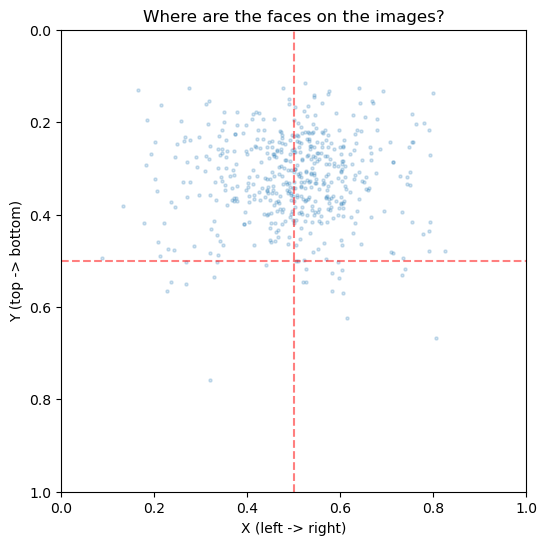

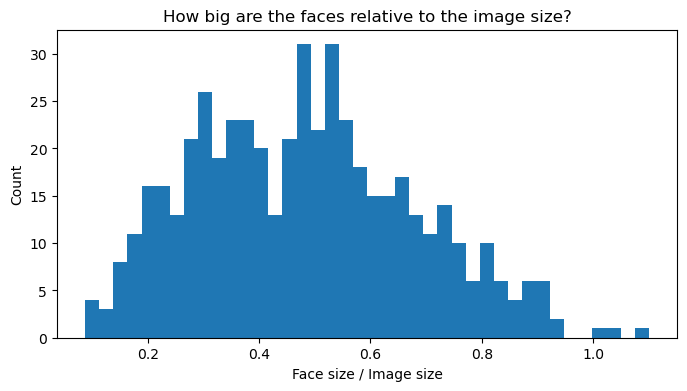

Average face size: 48.26%


In [27]:
# looking at face annotations, the .cat files contain coordinates of facial landmarks
def parse_cat_annotation(cat_path):
    with open(cat_path) as f:
        vals = list(map(int, f.read().split()))
    n = vals[0]
    points = np.array(vals[1:]).reshape(n, 2)
    return points

all_centers_x, all_centers_y = [], []
face_sizes = []

for p in image_paths[:500]:
    cat_path = Path(str(p) + ".cat")
    if not cat_path.exists():
        continue
    
    points = parse_cat_annotation(cat_path)
    img = Image.open(p)
    w, h = img.size
    
    cx = points[:, 0].mean() / w  #normalized to [0,1]
    cy = points[:, 1].mean() / h
    all_centers_x.append(cx)
    all_centers_y.append(cy)
    
    # face size relative to the image
    spread = max(points[:, 0].max() - points[:, 0].min(), points[:, 1].max() - points[:, 1].min())
    face_sizes.append(spread / min(w, h))

# where are the faces on the images?
plt.figure(figsize=(6, 6))
plt.scatter(all_centers_x, all_centers_y, alpha=0.2, s=5)
plt.xlim(0, 1)
plt.ylim(1, 0) #y is flipped because in images (0,0) is top-left
plt.xlabel("X (left -> right)")
plt.ylabel("Y (top -> bottom)")
plt.title("Where are the faces on the images?")
plt.axhline(0.5, color='red', linestyle='--', alpha=0.5)
plt.axvline(0.5, color='red', linestyle='--', alpha=0.5)
plt.show()

# how big are the faces relative to the image size?
plt.figure(figsize=(8, 4))
plt.hist(face_sizes, bins=40)
plt.xlabel("Face size / Image size")
plt.ylabel("Count")
plt.title("How big are the faces relative to the image size?")
plt.show()

print(f"Average face size: {np.mean(face_sizes):.2%}")

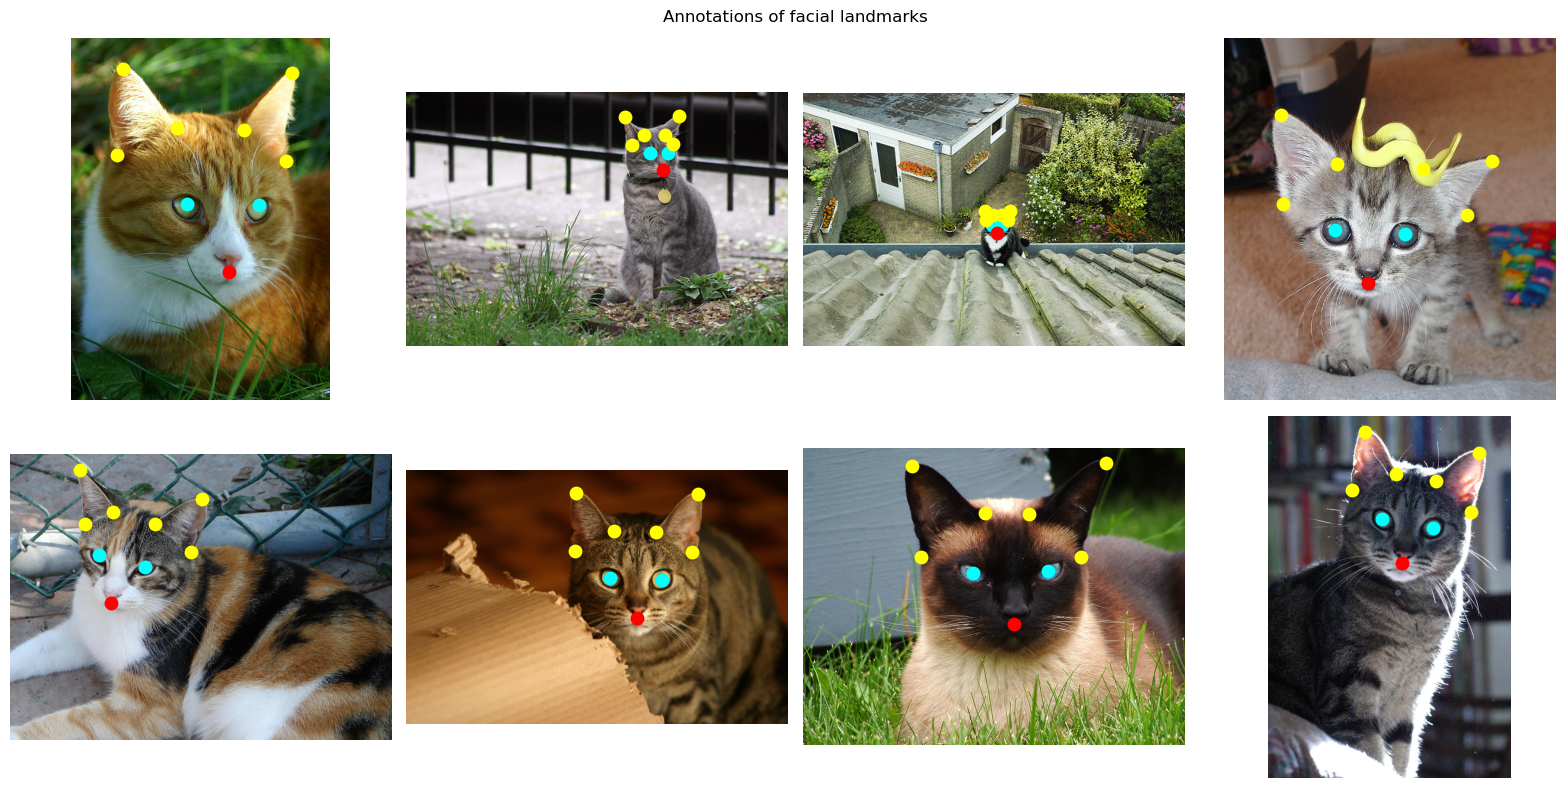

In [28]:
def show_annotations(image_path, ax):
    cat_path = Path(str(image_path) + ".cat")
    img = Image.open(image_path)
    points = parse_cat_annotation(cat_path)
    
    ax.imshow(img)
    
    labels = ['left eye', 'right eye', 'mouth', 'ear1', 'ear2', 'ear3', 'ear4', 'ear5', 'ear6']
    colors = ['cyan', 'cyan', 'red'] + ['yellow']*6
    
    for (x, y), label, color in zip(points, labels, colors):
        ax.scatter(x, y, c=color, s=80, zorder=5)
    
    ax.axis("off")

valid = [p for p in image_paths[:50] if Path(str(p)+".cat").exists()]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, p in zip(axes.flatten(), valid[:8]):
    show_annotations(p, ax)
plt.suptitle("Annotations of facial landmarks")
plt.tight_layout()
plt.show()

In [29]:
print("=" * 40)
print("Dataset Summary")
print("=" * 40)
print(f"Number of images: {len(image_paths)}")
print(f"Images with annotations: {sum(Path(str(p)+'.cat').exists() for p in image_paths)}")
print(f"Missing annotations: {sum(not Path(str(p)+'.cat').exists() for p in image_paths)}")
print(f"Minimum resolution: {min(widths)}x{min(heights)}")
print(f"Maximum resolution: {max(widths)}x{max(heights)}")
print(f"Average resolution: {np.mean(widths):.0f}x{np.mean(heights):.0f}")
print(f"Too small (<64px): {len(too_small)}")
print(f"Unique folders: {len(set(p.parent for p in image_paths))}")
print("=" * 40)

Dataset Summary
Number of images: 9997
Images with annotations: 9997
Missing annotations: 0
Minimum resolution: 135x101
Maximum resolution: 1024x1024
Average resolution: 605x520
Too small (<64px): 0
Unique folders: 7
